In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.plots import create_report, Adaptive_Plotter
from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file, get_path
from flonacomldft.internal_coordinates import Coordinates_mapping

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
id_is1 = 2466551

def get_adaptive_file(id, i, path):
    id_name = "{:d}{:d}".format(id, i)
    file = "results_adaptive_is1_{:s}/adaptative_sampling_is1_{:s}.pkl".format(id_name, id_name)
    return load_pickle_file(file, path)

In [3]:
adaptives = [get_adaptive_file(id_is1, i, "/mnt/home/amolina/ceph/EMT/3-adaptive") for i in range(0, 30, 6)]

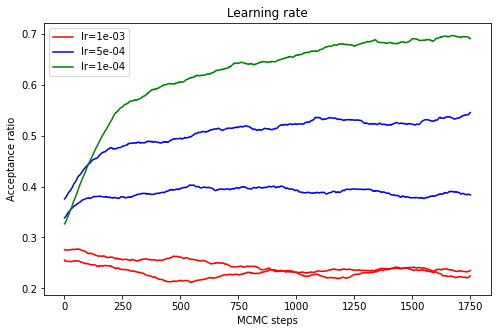

In [14]:
lr = np.array([1e-3, 5e-4, 1e-4])
c = np.array(['r', 'b', 'g'])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=250, axis=1)
    mask = lr == adaptive['args']['learning_rate']
    ax.plot(accs_avg, c=c[mask][0], label='lr={:.0e}'.format(adaptive['args']['learning_rate']))
ax.set_ylabel('Acceptance ratio')
ax.set_xlabel('MCMC steps')
ax.set_title('Learning rate')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()

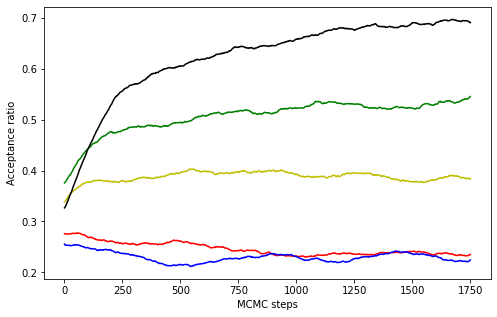

In [5]:
nb = np.array([4, 6, 8, 10, 12])
c = np.array(['r', 'b', 'g', 'y', 'k'])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=250, axis=1)
    mask = nb == adaptive['args']['n_blocks']
    ax.plot(accs_avg, c=c[mask][0])
ax.set_ylabel('Acceptance ratio')
ax.set_xlabel('MCMC steps')
plt.show()

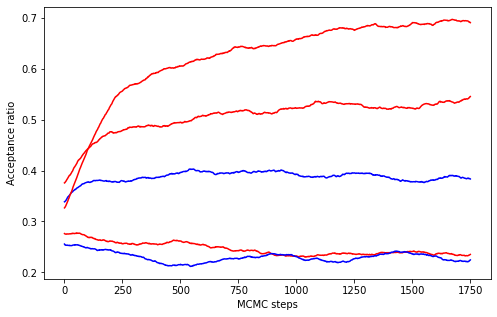

In [6]:
hdm = np.array([64, 96])
c = np.array(['r', 'b'])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=250, axis=1)
    mask = hdm == adaptive['args']['hidden_dim']
    ax.plot(accs_avg, c=c[mask][0])
ax.set_ylabel('Acceptance ratio')
ax.set_xlabel('MCMC steps')
plt.show()

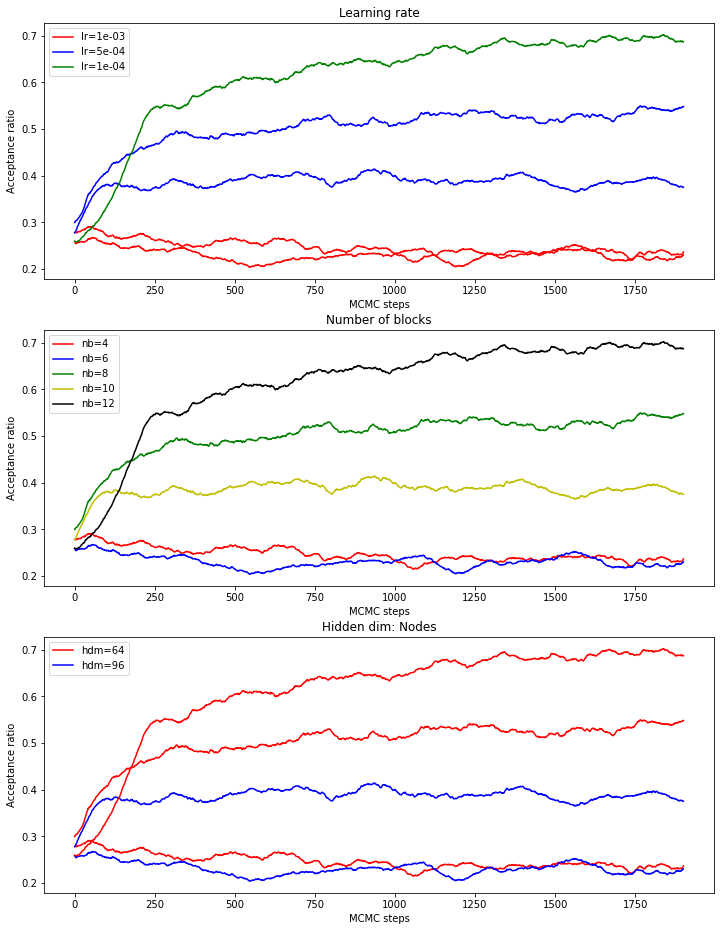

In [28]:
lr = np.array([1e-3, 5e-4, 1e-4])
c = np.array(['r', 'b', 'g'])

fig, axs = plt.subplots(3, 1, figsize=(12, 16))
for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=100, axis=1)
    mask = lr == adaptive['args']['learning_rate']
    axs[0].plot(accs_avg, c=c[mask][0], label='lr={:.0e}'.format(adaptive['args']['learning_rate']))
axs[0].set_ylabel('Acceptance ratio')
axs[0].set_xlabel('MCMC steps')
axs[0].set_title('Learning rate')

handles, labels = axs[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs[0].legend(by_label.values(), by_label.keys())


nb = np.array([4, 6, 8, 10, 12])
c = np.array(['r', 'b', 'g', 'y', 'k'])

for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=100, axis=1)
    mask = nb == adaptive['args']['n_blocks']
    axs[1].plot(accs_avg, c=c[mask][0], label='nb={:d}'.format(adaptive['args']['n_blocks']))
axs[1].set_ylabel('Acceptance ratio')
axs[1].set_xlabel('MCMC steps')
axs[1].set_title('Number of blocks')

handles, labels = axs[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs[1].legend(by_label.values(), by_label.keys())

hdm = np.array([64, 96])
c = np.array(['r', 'b'])

for adaptive in adaptives:
    accs = torch.stack(adaptive['accs']).reshape(-1, torch.stack(adaptive['accs']).shape[-1]).mean(axis=1).detach().numpy()
    accs_avg = avg_windows(accs, window_size=100, axis=1)
    mask = hdm == adaptive['args']['hidden_dim']
    axs[2].plot(accs_avg, c=c[mask][0], label='hdm={:d}'.format(adaptive['args']['hidden_dim']))
axs[2].set_ylabel('Acceptance ratio')
axs[2].set_xlabel('MCMC steps')
axs[2].set_title('Hidden dim: Nodes')

handles, labels = axs[2].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axs[2].legend(by_label.values(), by_label.keys())

In [29]:
adaptives[0]['args']

{'threads': None,
 'process_id': 24665510,
 'random_seed': 74,
 'folder_path': 'emt_andersen',
 'isomer_label': [1],
 'n_iter': 5,
 'learning_rate': 0.001,
 'batch_size': 128,
 'n_blocks': 4,
 'hidden_dim': 64,
 'hidden_depth': 6,
 'use_scheduler': False,
 'do_ratios': True,
 'n_prop': 100,
 'n_runs': 100,
 'n_chains': 100,
 'n_steps': 20,
 'energy_type': 'emt',
 'date_start': '20230711185754',
 'date_end': '2023-07-12 00:47:30',
 'algorithm': 'adaptive_sampling.py'}